In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

dataset= pd.read_csv('Teen_Mental_Health_Dataset.csv')
dataset[0:]

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [2]:
# 编码分类变量（修正版）
def encode_categorical_variables(df):
    
    df_encoded = df.copy()
    
    # 1. gender：二值化
    df_encoded['gender'] = (df_encoded['gender'] == 'male').astype(int)
    
    # 2. platform_usage：正确处理One-hot编码
    # 创建虚拟变量
    platform_dummies = pd.get_dummies(df_encoded['platform_usage'], prefix='platform')
    
    # 如果存在Both列，则根据Both列修正Instagram和TikTok列
    if 'platform_Both' in platform_dummies.columns:
        # 当Both为True时，将Instagram和TikTok也设为1
        both_mask = platform_dummies['platform_Both'] == 1
        platform_dummies.loc[both_mask, 'platform_Instagram'] = 1
        platform_dummies.loc[both_mask, 'platform_TikTok'] = 1
    
    # 删除Both列避免多重共线性
    platform_dummies = platform_dummies.drop('platform_Both', axis=1)
    
    # 转换为整数类型
    platform_dummies = platform_dummies.astype(int)
    
    df_encoded = pd.concat([df_encoded, platform_dummies], axis=1)
    df_encoded.drop('platform_usage', axis=1, inplace=True)
    
    # 3. social_interaction_level：保持顺序
    social_map = {'low': 0, 'medium': 1, 'high': 2}
    df_encoded['social_interaction_level'] = df_encoded['social_interaction_level'].map(social_map)
    
    return df_encoded

# 应用
dataset = encode_categorical_variables(dataset)
print("最终特征：", dataset.columns.tolist())
dataset[0:]

最终特征： ['age', 'gender', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'platform_Instagram', 'platform_TikTok']


C:\Users\施越杨\AppData\Local\Temp\ipykernel_275400\1448706646.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  platform_dummies.loc[both_mask, 'platform_Instagram'] = 1
C:\Users\施越杨\AppData\Local\Temp\ipykernel_275400\1448706646.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  platform_dummies.loc[both_mask, 'platform_TikTok'] = 1


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_Instagram,platform_TikTok
0,14,1,7.9,7.4,2.9,3.01,1.5,0,2,2,1,0,1,0
1,19,0,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,0,1
2,17,0,1.3,7.6,0.5,3.92,0.0,2,2,4,2,0,1,0
3,15,1,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,0,1
4,15,0,4.7,4.9,3.0,2.37,1.4,1,3,5,2,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,6.6,2.0,2.76,1.0,0,3,4,4,0,1,0
1196,16,1,2.3,8.0,1.9,2.12,0.4,2,7,4,4,0,1,1
1197,14,0,1.7,8.7,0.7,3.98,0.8,2,1,1,1,0,1,1
1198,15,1,3.9,8.5,2.1,3.19,0.6,2,7,9,9,0,1,1


In [3]:
# 使用向量化条件创建health列
# 条件1: depression_label为1
condition1 = dataset['depression_label'] == 1
# 条件2: depression_label为0 且 stress_level>=8 且 anxiety_level>=8
condition2 = (dataset['depression_label'] == 0) & (dataset['stress_level'] >= 8) & (dataset['anxiety_level'] >=8 )

# 满足任一条件则为1，否则为0
dataset['health_level'] = (condition1 | condition2).astype(int)
dataset = dataset.drop(['depression_label'], axis=1)

# 统计结果
print("\nhealth列统计：")
print(dataset['health_level'].value_counts())
dataset[:]


health列统计：
health_level
0    1068
1     132
Name: count, dtype: int64


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,platform_Instagram,platform_TikTok,health_level
0,14,1,7.9,7.4,2.9,3.01,1.5,0,2,2,1,1,0,0
1,19,0,1.9,8.0,2.9,3.22,0.8,2,8,1,10,0,1,0
2,17,0,1.3,7.6,0.5,3.92,0.0,2,2,4,2,1,0,0
3,15,1,7.4,6.9,1.6,3.48,0.8,1,1,7,9,0,1,0
4,15,0,4.7,4.9,3.0,2.37,1.4,1,3,5,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,6.6,2.0,2.76,1.0,0,3,4,4,1,0,0
1196,16,1,2.3,8.0,1.9,2.12,0.4,2,7,4,4,1,1,0
1197,14,0,1.7,8.7,0.7,3.98,0.8,2,1,1,1,1,1,0
1198,15,1,3.9,8.5,2.1,3.19,0.6,2,7,9,9,1,1,0


<Axes: >

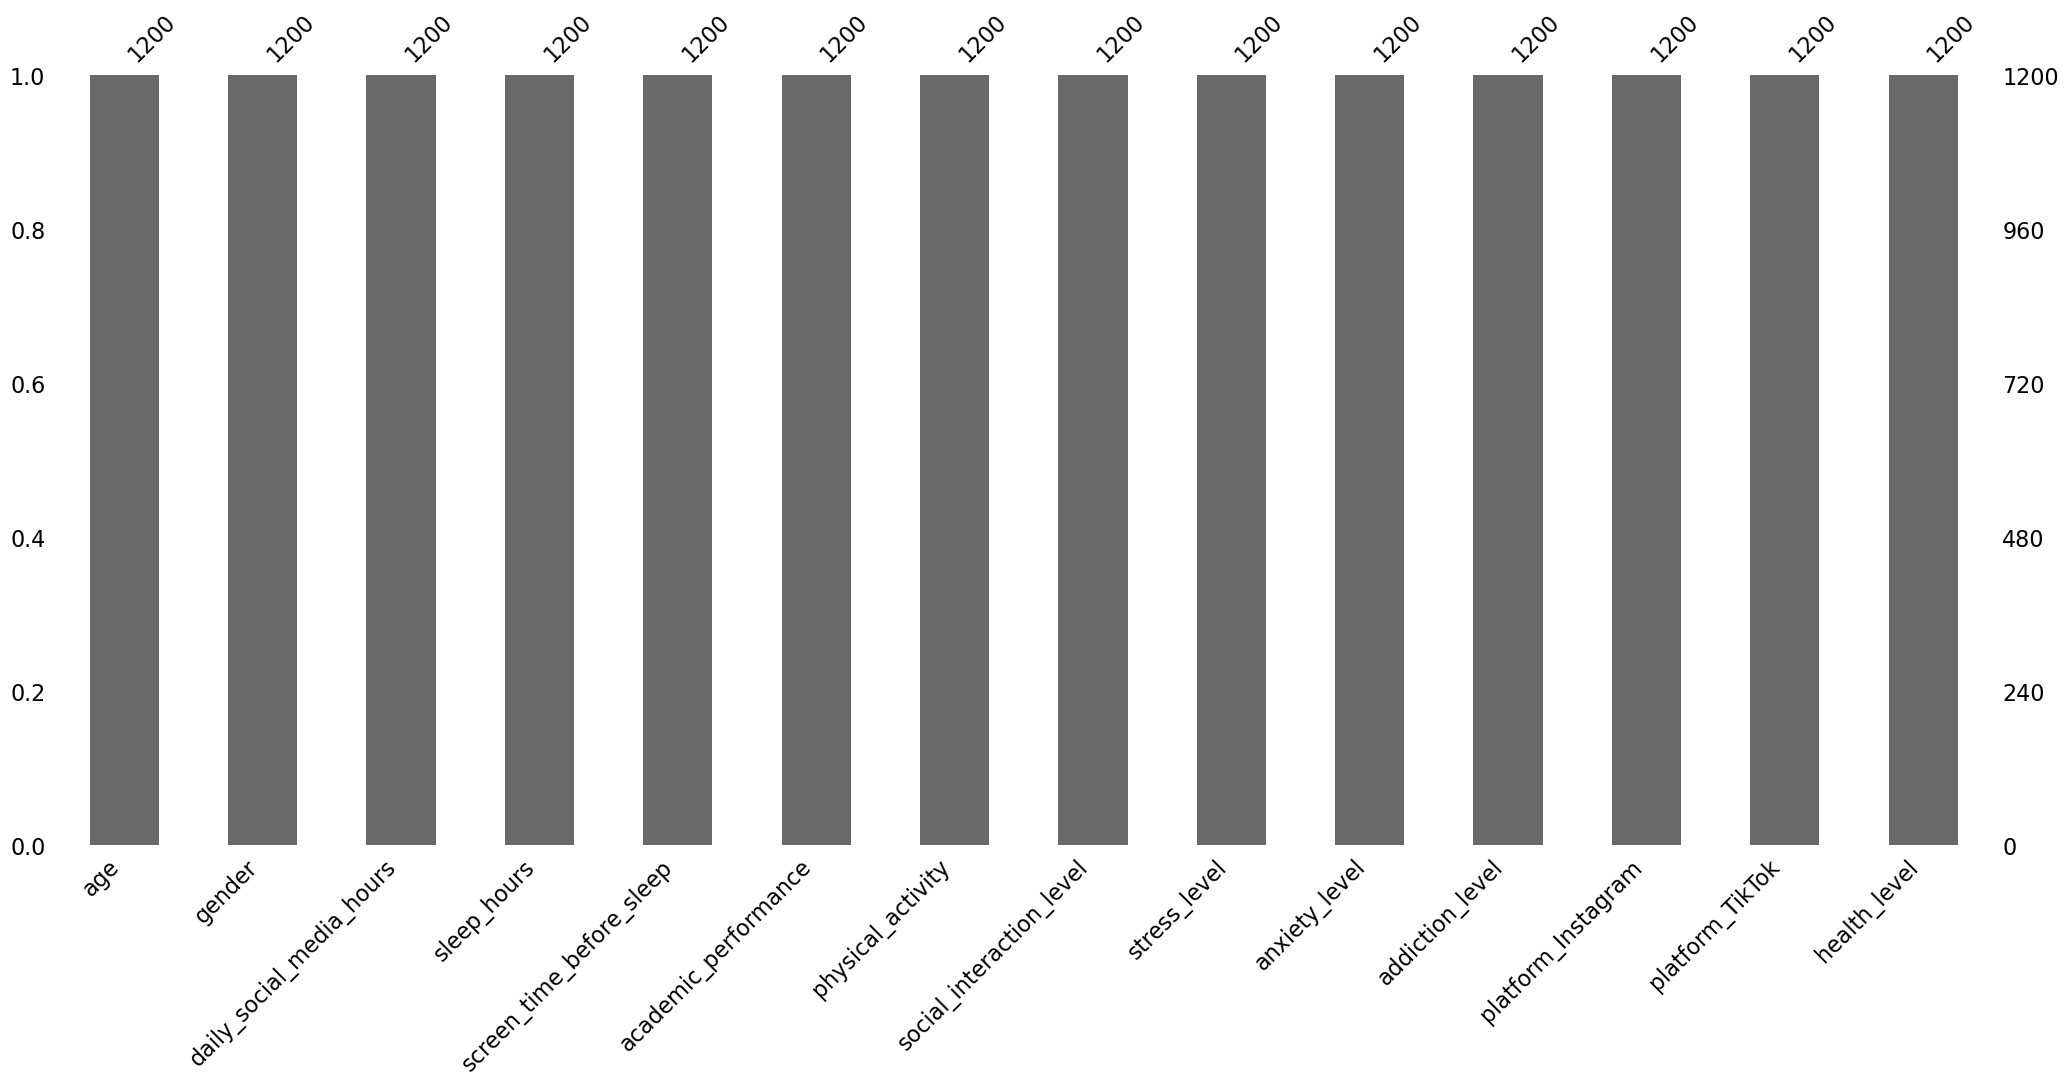

In [4]:
import missingno as msno
msno.bar(dataset)

In [5]:

# 数据质量检查报告
def data_quality_report(dataset):
    print("="*50)
    print("数据质量分析报告")
    print("="*50)
    
    # 1. 缺失值统计
    print("\n1. 缺失值分析：")
    missing = dataset.isnull().sum()
    missing_pct = missing / len(dataset) * 100
    missing_dataset = pd.DataFrame({'缺失数量': missing, '缺失比例(%)': missing_pct})
    print(missing_dataset[missing_dataset['缺失数量'] > 0])
    
    # 2. 异常值检测
    print("\n2. 异常值检测：")
    
    # health_level（应为0或1）
    invalid_dep = dataset[~dataset['health_level'].isin([0, 1])]
    print(f"health_level异常值数量: {len(invalid_dep)}")
    
    # stress_level（假设范围为1-10）
    invalid_stress = dataset[(dataset['stress_level'] < 1) | (dataset['stress_level'] > 10)]
    print(f"stress_level异常值数量: {len(invalid_stress)}")
    
    # anxiety_level（假设范围为1-10）
    invalid_anxiety = dataset[(dataset['anxiety_level'] < 1) | (dataset['anxiety_level'] > 10)]
    print(f"anxiety_level异常值数量: {len(invalid_anxiety)}")
    
    # 3. 重复值检查
    print("\n3. 重复值分析：")
    print(f"完全重复记录数: {dataset.duplicated().sum()}")
    
    # 4. 数据类型
    print("\n4. 数据类型：")
    print(dataset.dtypes)
    
    # 5. 描述性统计（用于发现异常）
    print("\n5. 描述性统计：")
    numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
    print(dataset[numeric_cols].describe())

# 执行检查
data_quality_report(dataset)

数据质量分析报告

1. 缺失值分析：
Empty DataFrame
Columns: [缺失数量, 缺失比例(%)]
Index: []

2. 异常值检测：
health_level异常值数量: 0
stress_level异常值数量: 0
anxiety_level异常值数量: 0

3. 重复值分析：
完全重复记录数: 0

4. 数据类型：
age                           int64
gender                        int32
daily_social_media_hours    float64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level      int64
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
platform_Instagram            int32
platform_TikTok               int32
health_level                  int32
dtype: object

5. 描述性统计：
               age  daily_social_media_hours  sleep_hours  \
count  1200.000000               1200.000000  1200.000000   
mean     15.928333                  4.536667     6.449417   
std       2.021947                  2.029599     1.442677   
min      13.000000                  1.000000     

In [6]:
X=dataset.iloc[:,0:13].values
Y=dataset.iloc[:,-1].values
X

array([[14. ,  1. ,  7.9, ...,  1. ,  1. ,  0. ],
       [19. ,  0. ,  1.9, ..., 10. ,  0. ,  1. ],
       [17. ,  0. ,  1.3, ...,  2. ,  1. ,  0. ],
       ...,
       [14. ,  0. ,  1.7, ...,  1. ,  1. ,  1. ],
       [15. ,  1. ,  3.9, ...,  9. ,  1. ,  1. ],
       [16. ,  0. ,  4.7, ...,  3. ,  0. ,  1. ]])

In [7]:
# 1. 标准化数据
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.95409872,  0.97530483,  1.6578328 , ..., -1.613389  ,
         0.70445678, -1.38553529],
       [ 1.51979597, -1.02532046, -1.29964891, ...,  1.56744364,
        -1.41953351,  0.72174272],
       [ 0.5302381 , -1.02532046, -1.59539708, ..., -1.25996315,
         0.70445678, -1.38553529],
       ...,
       [-0.95409872, -1.02532046, -1.39823163, ..., -1.613389  ,
         0.70445678,  0.72174272],
       [-0.45931978,  0.97530483, -0.31382167, ...,  1.21401779,
         0.70445678,  0.72174272],
       [ 0.03545916, -1.02532046,  0.08050922, ..., -0.9065373 ,
        -1.41953351,  0.72174272]])

In [8]:
# 2. 计算协方差矩阵
covariance_matrix = np.cov(X_scaled, rowvar=False)
covariance_matrix

array([[ 1.00083403e+00,  1.07944240e-02, -6.64051380e-03,
         1.53089056e-03,  7.56748939e-02, -1.39842253e-02,
         1.10954124e-02,  1.62038602e-02, -3.12342000e-02,
         2.63849002e-02,  3.82973316e-02, -1.27294856e-02,
         2.22136417e-02],
       [ 1.07944240e-02,  1.00083403e+00,  1.13911393e-02,
        -3.18092135e-02, -2.67979271e-02, -1.72084197e-02,
         1.71533767e-02, -3.80781295e-02,  7.94162806e-03,
        -1.72505197e-02,  2.74366614e-02, -3.63264504e-03,
         9.27386723e-03],
       [-6.64051380e-03,  1.13911393e-02,  1.00083403e+00,
        -9.48007451e-03,  3.58073144e-02,  1.31899708e-02,
         2.55672821e-02, -1.55368447e-02,  3.07233447e-02,
         2.78579712e-02, -2.49848865e-02,  1.91517648e-03,
        -8.08267490e-03],
       [ 1.53089056e-03, -3.18092135e-02, -9.48007451e-03,
         1.00083403e+00,  1.02438180e-02,  2.18847213e-02,
         1.27112620e-02,  5.42490005e-03, -1.09883813e-02,
        -1.18886001e-02, -5.48835970e

In [9]:
# 3. 计算特征值和特征向量
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
print(eigenvalues, eigenvectors)

[1.52948043 0.48596703 0.84693472 1.13225178 1.08597797 1.07217172
 1.04893342 1.03816834 0.91808617 0.93121779 0.95137043 0.99526327
 0.97501931] [[ 5.89945840e-02 -1.96576713e-02 -2.11670793e-01 -5.01846149e-01
  -1.68841391e-02  3.46160315e-01 -6.98052621e-02  2.20969237e-01
  -6.54943119e-01 -1.01878132e-01 -2.00956926e-01  2.14137841e-01
  -9.92836613e-03]
 [ 1.72765819e-02  1.28782228e-04  2.07973933e-01  2.98229699e-02
   5.49757309e-01 -1.02931738e-01 -1.71266316e-01  3.23497837e-01
   2.10432288e-01 -4.95709458e-01 -1.92650274e-01  3.03941653e-01
  -2.98736711e-01]
 [-1.41096272e-02  1.13146746e-02 -3.57204610e-01 -5.20614560e-02
   6.85660991e-02 -2.01024768e-01  5.91266924e-01  4.83769544e-01
   8.86187035e-02 -2.43240111e-01  1.64053329e-01 -1.20129322e-01
   3.63678399e-01]
 [ 1.16085061e-03 -8.08590402e-03 -1.84731290e-01  1.92888577e-01
  -4.91793986e-01  2.35883034e-01  1.73433541e-01  7.72538729e-02
   3.63080480e-01 -2.44567597e-02 -5.28841218e-01  4.25781300e-01
  -4

In [10]:
# 4. 排序特征值和特征向量
eigenvectors = eigenvectors[:, np.argsort(-eigenvalues)] 
    # 按特征值从大到小排序
eigenvalues = eigenvalues[np.argsort(-eigenvalues)]

eigenvalues

array([1.52948043, 1.13225178, 1.08597797, 1.07217172, 1.04893342,
       1.03816834, 0.99526327, 0.97501931, 0.95137043, 0.93121779,
       0.91808617, 0.84693472, 0.48596703])

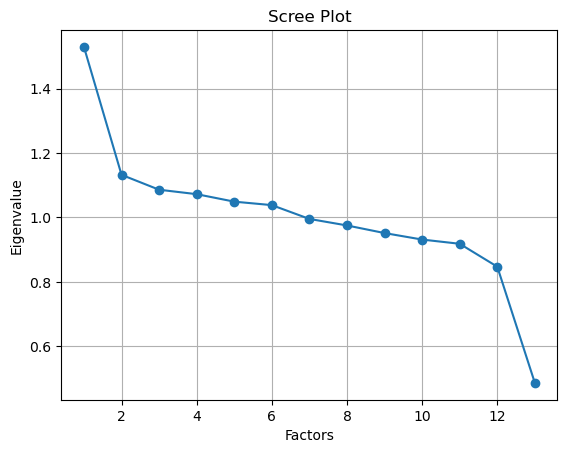

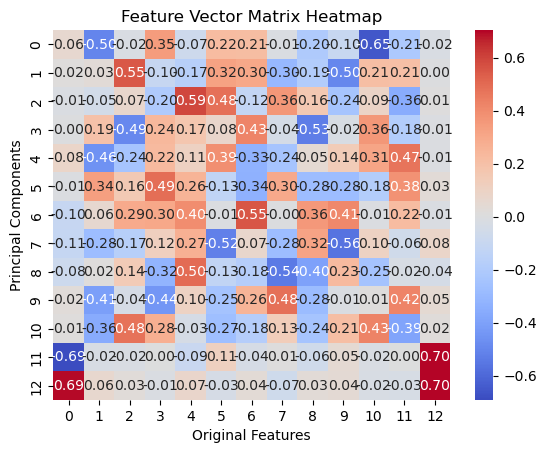

In [11]:
#绘制排序后的特征值
plt.plot(np.arange(1, len(eigenvalues) + 1), eigenvalues, marker='o')
 
# 显示图的标题和xy轴的名字
plt.title("Scree Plot")
plt.xlabel("Factors")
plt.ylabel("Eigenvalue")
 
plt.grid()  # 显示网格
plt.show()  # 显示图形

import seaborn as sns
import matplotlib.pyplot as plt

# 假设 feature_vectors 是特征向量矩阵
# 使用热力图绘制特征向量矩阵
sns.heatmap(eigenvectors, cmap='coolwarm', annot=True, fmt=".2f")

# 添加标题和标签
plt.title("Feature Vector Matrix Heatmap")
plt.xlabel("Original Features")
plt.ylabel("Principal Components")

# 显示热力图
plt.show()

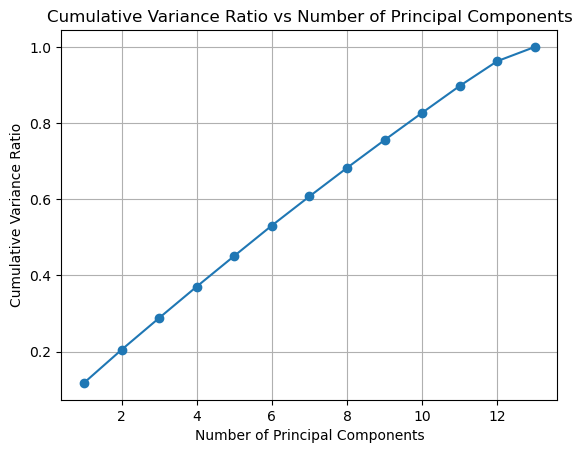

In [12]:
# 4. 计算特征值（累计）贡献度
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)
cumulative_explained_variance_ratio

import matplotlib.pyplot as plt

# 假设eigenvalues是特征值的数组，已经通过np.argsort()排序过了
# 使用折线图展示特征值的累计贡献度
cumulative_variance_ratio = np.cumsum(eigenvalues) / np.sum(eigenvalues)
plt.plot(np.arange(1, len(eigenvalues) + 1), cumulative_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Ratio')
plt.title('Cumulative Variance Ratio vs Number of Principal Components')
plt.grid(True)
plt.show()


cumulative_contributions = np.cumsum(eigenvalues) / np.sum(eigenvalues)

In [13]:
# 5.根据累计贡献度阈值，选择主成分
n_components = np.argmax(cumulative_contributions >= 0.5) + 1
print("满足累计贡献度阈值为0.5的主成分数量：", n_components)

# 7. 投影数据
X_pca = X_scaled.dot(eigenvectors[:, :n_components])

print("降维后的数据矩阵 X_pca:\n", X_pca)

data = pd.DataFrame(X_pca)
data.to_csv('X_pca_data.csv', index=False)

X_pca = data.iloc[:,0:5].values
X_pca

满足累计贡献度阈值为0.5的主成分数量： 6
降维后的数据矩阵 X_pca:
 [[-1.29819032e+00  1.17310948e+00 -5.41724946e-01  3.99612536e-01
   3.45486459e-01  3.22958090e+00]
 [ 1.50803038e+00 -1.31988618e+00 -8.78938523e-01  2.60336259e+00
   3.79289678e-01 -9.45477199e-01]
 [-1.45518038e+00  1.39114272e+00 -1.94265014e+00  1.13184018e+00
  -1.56223749e+00 -1.71497122e+00]
 ...
 [-2.03891284e-01  2.93837228e+00 -2.05717567e+00  1.74313139e+00
  -7.23047238e-01 -1.46853867e+00]
 [-1.84981007e-02 -8.41757858e-01 -4.89127477e-02 -2.09441008e-03
   4.74909670e-01 -9.73041612e-01]
 [ 1.41237244e+00  5.62398795e-01 -8.46583087e-01 -6.71234085e-01
   2.03601328e-01 -7.31533612e-01]]


array([[-1.29819032e+00,  1.17310948e+00, -5.41724946e-01,
         3.99612536e-01,  3.45486459e-01],
       [ 1.50803038e+00, -1.31988618e+00, -8.78938523e-01,
         2.60336259e+00,  3.79289678e-01],
       [-1.45518038e+00,  1.39114272e+00, -1.94265014e+00,
         1.13184018e+00, -1.56223749e+00],
       ...,
       [-2.03891284e-01,  2.93837228e+00, -2.05717567e+00,
         1.74313139e+00, -7.23047238e-01],
       [-1.84981007e-02, -8.41757858e-01, -4.89127477e-02,
        -2.09441008e-03,  4.74909670e-01],
       [ 1.41237244e+00,  5.62398795e-01, -8.46583087e-01,
        -6.71234085e-01,  2.03601328e-01]])

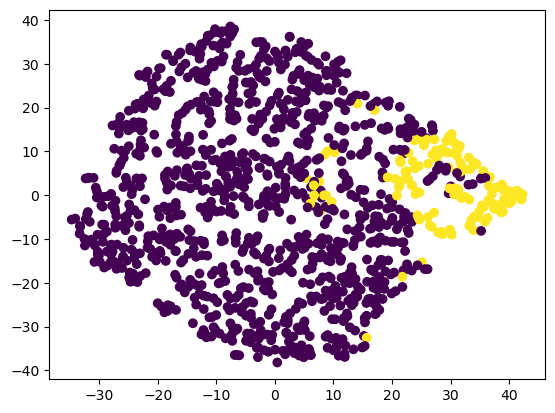

In [14]:
from sklearn.manifold import TSNE

# 初始化t-SNE对象
tsne = TSNE(n_components=2, random_state=42)

# 将数据降维到2维
X_tsne = tsne.fit_transform(X)
data = pd.DataFrame(X_tsne)
data.to_csv('X_tsne_data.csv', index=False)

# 绘制散点图
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=Y)
plt.show()

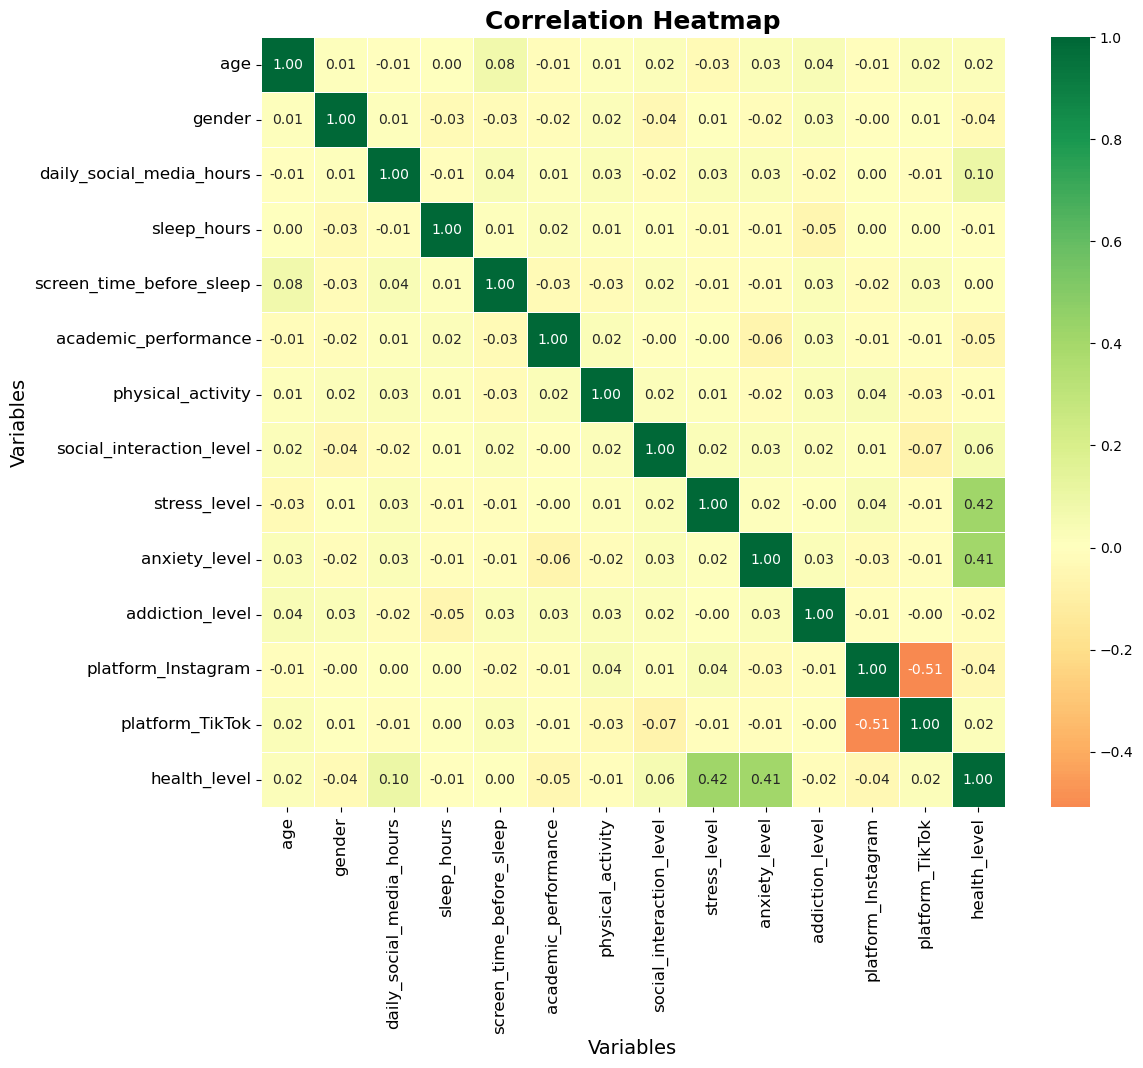

                               age    gender  daily_social_media_hours  \
age                       1.000000  0.010785                 -0.006635   
gender                    0.010785  1.000000                  0.011382   
daily_social_media_hours -0.006635  0.011382                  1.000000   
sleep_hours               0.001530 -0.031783                 -0.009472   
screen_time_before_sleep  0.075612 -0.026776                  0.035777   
academic_performance     -0.013973 -0.017194                  0.013179   
physical_activity         0.011086  0.017139                  0.025546   
social_interaction_level  0.016190 -0.038046                 -0.015524   
stress_level             -0.031208  0.007935                  0.030698   
anxiety_level             0.026363 -0.017236                  0.027835   
addiction_level           0.038265  0.027414                 -0.024964   
platform_Instagram       -0.012719 -0.003630                  0.001914   
platform_TikTok           0.022195  0.

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr = dataset.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='RdYlGn', center=0, annot=True, fmt='.2f', linewidths=.5, ax=ax)
# Set the axis labels and title
ax.set_xlabel('Variables', fontsize=14)
ax.set_ylabel('Variables', fontsize=14)
ax.set_title('Correlation Heatmap', fontsize=18, fontweight='bold')
# Increase the font size of the annotations
ax.tick_params(axis='both', labelsize=12)
# Show the plot
plt.savefig('Correlation Heatmap.png')
plt.show()
# Output the correlation coefficients of all variables
print(corr)

In [19]:
#logistic回归
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score, roc_curve, auc

# 将class列作为标签
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
# 训练模型
model = LogisticRegression()
model.fit(X_train, y_train)
# 预测结果
y_pred = model.predict(X_test)
# 评估模型
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# 输出结果
print(f"Accuracy: {accuracy:.5f}")
print("Confusion matrix:")
print(confusion)
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.95000
Confusion matrix:
[[150   4]
 [  5  21]]
Precision: 0.84000
Recall: 0.80769
F1 Score: 0.82353


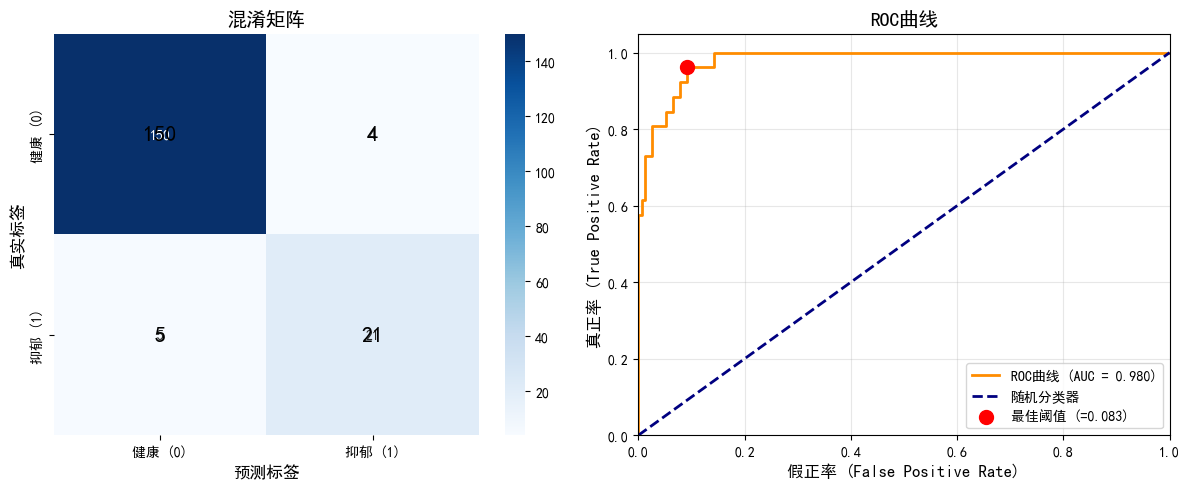

ROC曲线AUC值: 0.97977
混淆矩阵已绘制
图表已保存: roc_confusion_matrix.png


In [20]:
# plot_roc_confusion.py
# 绘制ROC曲线和混淆矩阵图

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 将class列作为标签
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 训练模型
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 预测结果
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # 获取预测概率

# 计算混淆矩阵
confusion = confusion_matrix(y_test, y_pred)

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 图1：混淆矩阵热力图
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['健康 (0)', '抑郁 (1)'],
            yticklabels=['健康 (0)', '抑郁 (1)'])
ax1.set_title('混淆矩阵', fontsize=14)
ax1.set_xlabel('预测标签', fontsize=12)
ax1.set_ylabel('真实标签', fontsize=12)

# 在热力图上添加数值标注（可选）
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax1.text(j+0.5, i+0.5, str(confusion[i, j]), 
                 ha='center', va='center', fontsize=16, fontweight='bold')

# 图2：ROC曲线
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲线 (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机分类器')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('假正率 (False Positive Rate)', fontsize=12)
ax2.set_ylabel('真正率 (True Positive Rate)', fontsize=12)
ax2.set_title('ROC曲线', fontsize=14)
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

# 可选：标注最佳阈值点
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax2.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
            zorder=5, label=f'最佳阈值 (={optimal_threshold:.3f})')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig('roc_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"ROC曲线AUC值: {roc_auc:.5f}")
print(f"混淆矩阵已绘制")
print("图表已保存: roc_confusion_matrix.png")

In [21]:
#主成分logistic
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

Y=dataset.iloc[:,-1]
data = pd.read_csv('X_pca_data.csv')
X_pca = data.iloc[:,0:7].values
#主成分分析后的划分
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size = 0.15, random_state = 0)
# 训练模型
model = LogisticRegression()
model.fit(X_train, y_train)
# 预测结果
y_pred = model.predict(X_test)
# 评估模型
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# 输出结果
print(f"Accuracy: {accuracy:.5f}")
print("Confusion matrix:")
print(confusion)
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.93333
Confusion matrix:
[[158   5]
 [  7  10]]
Precision: 0.66667
Recall: 0.58824
F1 Score: 0.62500


In [22]:
#tsne-logistic
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

Y=dataset.iloc[:,-1]
data = pd.read_csv('X_tsne_data.csv')
X_pca = data.iloc[:,0:7].values
#主成分分析后的划分
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size = 0.15, random_state = 0)
# 训练模型
model = LogisticRegression()
model.fit(X_train, y_train)
# 预测结果
y_pred = model.predict(X_test)
# 评估模型
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# 输出结果
print(f"Accuracy: {accuracy:.5f}")
print("Confusion matrix:")
print(confusion)
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.96111
Confusion matrix:
[[161   2]
 [  5  12]]
Precision: 0.85714
Recall: 0.70588
F1 Score: 0.77419


In [23]:
#决策树
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd

# 将class列作为标签
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
# 训练模型
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# 预测结果
y_pred = model.predict(X_test)
# 评估模型
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# 输出结果
print(f"Accuracy: {accuracy:.5f}")
print("Confusion matrix:")
print(confusion)
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.99444
Confusion matrix:
[[154   0]
 [  1  25]]
Precision: 1.00000
Recall: 0.96154
F1 Score: 0.98039


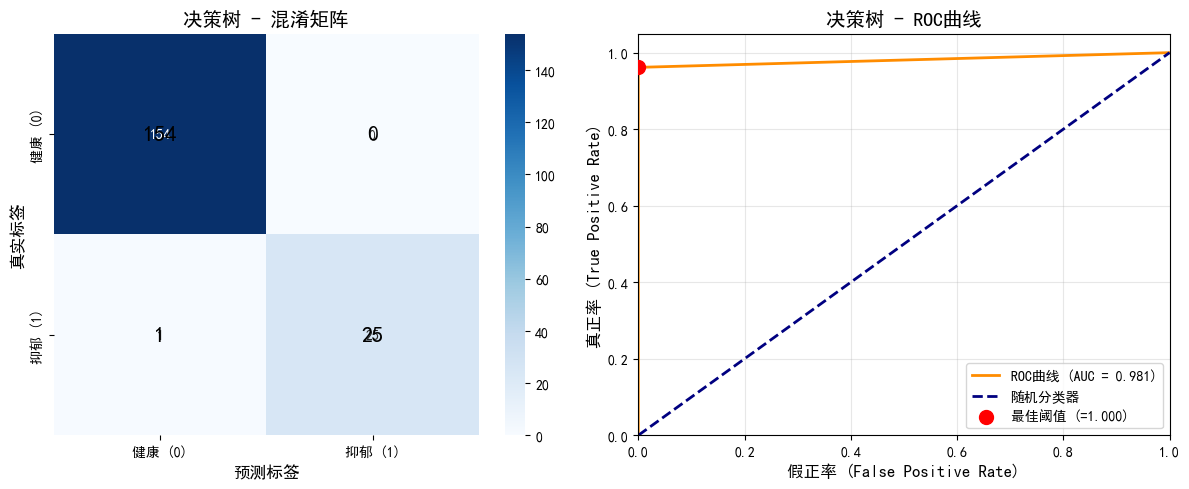

决策树模型 AUC值: 0.98077
图表已保存: decision_tree_roc_confusion.png


In [24]:
# plot_decision_tree.py
# 绘制决策树的ROC曲线和混淆矩阵图

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 将class列作为标签
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 训练模型
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 预测结果
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # 获取预测概率

# 计算混淆矩阵
confusion = confusion_matrix(y_test, y_pred)

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 图1：混淆矩阵热力图
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['健康 (0)', '抑郁 (1)'],
            yticklabels=['健康 (0)', '抑郁 (1)'])
ax1.set_title('决策树 - 混淆矩阵', fontsize=14)
ax1.set_xlabel('预测标签', fontsize=12)
ax1.set_ylabel('真实标签', fontsize=12)

# 在热力图上添加数值标注
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax1.text(j+0.5, i+0.5, str(confusion[i, j]), 
                 ha='center', va='center', fontsize=16, fontweight='bold')

# 图2：ROC曲线
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC曲线 (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='随机分类器')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('假正率 (False Positive Rate)', fontsize=12)
ax2.set_ylabel('真正率 (True Positive Rate)', fontsize=12)
ax2.set_title('决策树 - ROC曲线', fontsize=14)
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

# 可选：标注最佳阈值点
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax2.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
            zorder=5, label=f'最佳阈值 (={optimal_threshold:.3f})')
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig('decision_tree_roc_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"决策树模型 AUC值: {roc_auc:.5f}")
print("图表已保存: decision_tree_roc_confusion.png")

In [25]:
#主成分决策树
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

Y=dataset.iloc[:,-1]
data = pd.read_csv('X_pca_data.csv')
X_pca = data.iloc[:,0:7].values
#主成分分析后的划分
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size = 0.15, random_state = 0)
# 训练模型
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# 预测结果
y_pred = model.predict(X_test)
# 评估模型
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# 输出结果
print(f"Accuracy: {accuracy:.5f}")
print("Confusion matrix:")
print(confusion)
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.86667
Confusion matrix:
[[148  15]
 [  9   8]]
Precision: 0.34783
Recall: 0.47059
F1 Score: 0.40000


In [26]:
#决策树 tsne降维
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd

Y=dataset.iloc[:,-1]
data = pd.read_csv('X_tsne_data.csv')
X_tsne = data.iloc[:,0:5].values
#tsne降维分析后的划分
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tsne, Y, test_size = 0.15, random_state = 0)
# 训练模型
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# 预测结果
y_pred = model.predict(X_test)
# 评估模型
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# 输出结果
print(f"Accuracy: {accuracy:.5f}")
print("Confusion matrix:")
print(confusion)
print(f"Precision: {precision:.5f}")
print(f"Recall: {recall:.5f}")
print(f"F1 Score: {f1:.5f}")

Accuracy: 0.95556
Confusion matrix:
[[160   3]
 [  5  12]]
Precision: 0.80000
Recall: 0.70588
F1 Score: 0.75000


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

dataset.head()

X=dataset.iloc[:,0:-1]
y=dataset.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [28]:
#随机森林
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

c1 = RandomForestClassifier(n_estimators=10, max_depth=None,min_samples_split=2, random_state=0)#随机森林分类器
scores = cross_val_score(c1, X_train, y_train)
print(scores.mean())

0.9862745098039216


In [29]:
#extra树分类器
c2 = ExtraTreesClassifier(n_estimators=10, max_depth=None,min_samples_split=2, random_state=0)#extra树分类器
scores = cross_val_score(c2, X_train, y_train)
print(scores.mean())

0.9372549019607843


In [30]:
#使用主成分后
Y=dataset.iloc[:,-1]
data = pd.read_csv('X_pca_data.csv')
X_pca=data.iloc[:,0:-1]
X_train, X_test, y_train, y_test = train_test_split(X_pca, Y, test_size=0.15, random_state=42)

In [31]:
#随机森林
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

c1 = RandomForestClassifier(n_estimators=10, max_depth=None,min_samples_split=2, random_state=0)#随机森林分类器
scores = cross_val_score(c1, X_train, y_train)
print(scores.mean()) 

0.9127450980392157


In [32]:
#extra树分类器
c2 = ExtraTreesClassifier(n_estimators=10, max_depth=None,min_samples_split=2, random_state=0)#extra树分类器
scores = cross_val_score(c2, X_train, y_train)
print(scores.mean())

0.9137254901960784


In [33]:
#使用t-SNE后
Y=dataset.iloc[:,-1]
data = pd.read_csv('X_tsne_data.csv')
X_tsne=data.iloc[:,0:2]
X_train, X_test, y_train, y_test = train_test_split(X_tsne, Y, test_size=0.15, random_state=42)

In [34]:
#随机森林
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

c1 = RandomForestClassifier(n_estimators=10, max_depth=None,min_samples_split=2, random_state=0)#随机森林分类器
scores = cross_val_score(c1, X_train, y_train)
print(scores.mean()) 

0.9578431372549019


In [35]:
#extra树分类器
c2 = ExtraTreesClassifier(n_estimators=10, max_depth=None,min_samples_split=2, random_state=0)#extra树分类器
scores = cross_val_score(c2, X_train, y_train)
print(scores.mean())

0.9666666666666666


In [40]:
# 导入相关库
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 标准化特征
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 构建神经网络模型（修改后）
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # 输入层
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 编译模型
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 训练模型
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# 可选：评估模型
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"测试准确率: {test_accuracy:.5f}")

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9020 - loss: 0.3613 - val_accuracy: 0.8676 - val_loss: 0.3329
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9032 - loss: 0.2340 - val_accuracy: 0.8676 - val_loss: 0.2489
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9044 - loss: 0.1788 - val_accuracy: 0.8971 - val_loss: 0.1946
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9473 - loss: 0.1448 - val_accuracy: 0.9216 - val_loss: 0.1616
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9632 - loss: 0.1094 - val_accuracy: 0.9559 - val_loss: 0.1278
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9767 - loss: 0.0880 - val_accuracy: 0.9510 - val_loss: 0.1111
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9804 - loss: 0.0725 - val_accuracy: 0.9461 - val_loss: 0.1015
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9853 - loss: 0.0614 - val_accuracy: 0.9559 - val_loss

In [41]:
# 在测试集上评估模型
y_pred = model.predict(X_test).ravel()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [42]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, threshold = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

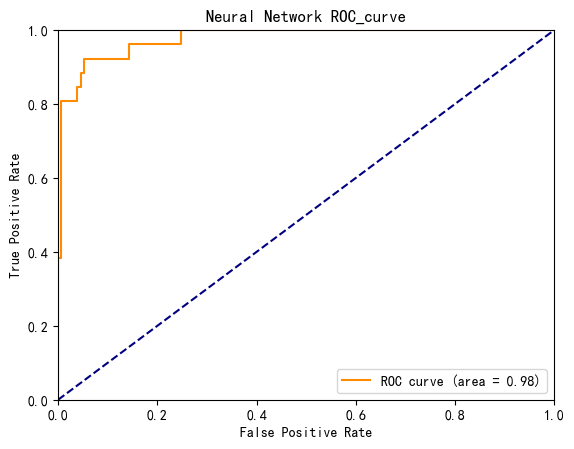

In [43]:
# 绘制ROC曲线
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network ROC_curve')
plt.legend(loc="lower right")
plt.show()